In [9]:
from GNN import GATv2SequenceModel
from dataset_processing_test import DatasetProcessing
import json
import ijson
import os
import networkx as nx
from torch_geometric.utils import to_networkx
import random
import torch
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
dataset_process=DatasetProcessing()
for file_name in [file for file in os.listdir("data") if file.endswith('.json')]:
  with open("data/" + file_name) as json_file:
    data_dict = json.load(json_file)
graphs=dataset_process.modified([data_dict])
graphs=(graphs[0][2:-1],graphs[1][2:-1])
sequences=dataset_process.create_sequence_and_labels(graphs[0],graphs[1],5)
graphs_sequences=sequences[0]
label_sequences=sequences[1]

WORKING DIRECTORY::::c:\Users\Kasza Róbert\Pictures\SZAKDOGA\OE_Szakdolgozat\src\models\neural_networks\working


In [11]:
with open("mapper.json","r") as f:
    mapper_d=json.load(f)     

In [12]:
graphs_sequences[31]

[Data(x=[9, 13], edge_index=[2, 2], edge_attr=[4, 1], node_ids=[9]),
 Data(x=[9, 13], edge_index=[2, 2], edge_attr=[4, 1], node_ids=[9]),
 Data(x=[9, 13], edge_index=[2, 2], edge_attr=[4, 1], node_ids=[9]),
 Data(x=[9, 13], edge_index=[2, 2], edge_attr=[4, 1], node_ids=[9]),
 Data(x=[9, 13], edge_index=[2, 2], edge_attr=[4, 1], node_ids=[9])]

In [13]:
len(label_sequences[574])

15

In [14]:
label_sequences[843]

[None, [1, 3], [1, 3], [1, 3], [1, 3], [1, 3], [1, 3], [1, 3], [1, 3], [1, 3]]

In [15]:
next_action=[]
speed_change=[]
for i in label_sequences:
    for label in i[1:]:
        next_action.append(label[0])
        speed_change.append(label[1])

data = {
    'next_action': next_action,
    'speed_change': speed_change,

}

# Create a DataFrame from the dictionary
df = pd.DataFrame(data)

for column in df.columns:
    print(f"Unique value counts in column '{column}':")
    print(df[column].value_counts())
    print()

Unique value counts in column 'next_action':
next_action
0    20455
1    15691
2     3068
4     2303
3      898
5      807
Name: count, dtype: int64

Unique value counts in column 'speed_change':
speed_change
5    19052
1    12649
3    10912
4      289
0      204
2      116
Name: count, dtype: int64



In [ ]:
print()

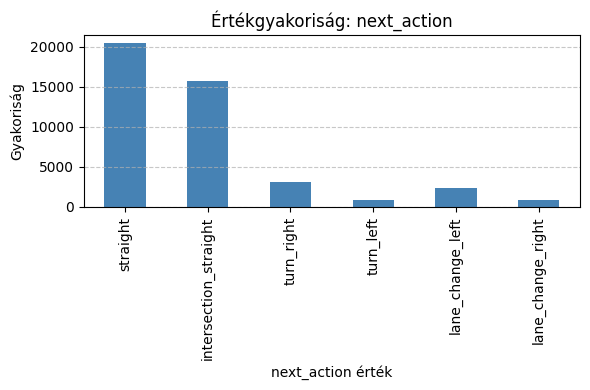

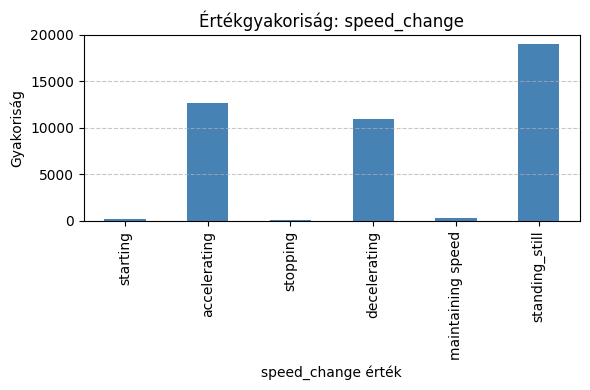

In [ ]:
for column in df.columns:
    value_counts = df[column].value_counts().sort_index()

    if column in mapper_d:
        reverse_mapper = {v: k for k, v in mapper_d[column].items()}
        value_counts.index = value_counts.index.map(reverse_mapper)

    plt.figure(figsize=(6, 4))
    value_counts.plot(kind='bar', color='steelblue')
    plt.title(f"Értékgyakoriság: {column}")
    plt.xlabel(f"{column} érték")
    plt.ylabel("Gyakoriság")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
